## Introduction
### Customer churn has become an important challenge for telecommunications companies because losing customers can reduce revenue and increase acquisition costs. This project has investigated the use of machine learning to predict whether customers are likely to leave a telecommunications service. The analysis has used customer demographic, service, contract, and billing information to identify patterns associated with churn. Data preprocessing, feature engineering, and exploratory analysis have prepared the dataset for modelling. Logistic Regression and Random Forest have then been trained and compared using cross-validation and multiple evaluation metrics. The results have supported more targeted customer-retention decisions and improved understanding of churn risk.

## Problem Statement: 
### This project has been concerned with foreseeing customer churn in telecommunications. Customer churn has been defined as the discontinuation of services by customers. Historical customer, account and service data have been used to derive a likelihood of customer departures for each customer. It uses a machine learning technique to detect the patterns related to customer churn. The project is keen to help the telecommunications company gain useful predictive insights that can help guide proactive customer-retention decisions. This has enabled the firm to detect problematic customer churn and then counter it with more coherent actions that keep customers satisfied and lose less.

## Business Problem and Importance
### Customer attrition has been a crucial business challenge in the telecom industry since departing customers translate into lost revenue and a greater need to acquire new customers. The company also has extra marketing and service expenses in acquiring new customers. The change from reactive to proactive has been facilitated by the use of a predictive model that leverages information about customers' attributes before they make the decision to churn (Chang et al. 2024). This insight has helped the company to make successful retention measures earlier. The model has therefore enabled more targeted interventions – rather than generic interventions for all customers as had previously been done – with a focus on what works, therefore helping the company focus its resources on those potential customers who have a higher probability of leaving.

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

## Data Collection and Dataset Description
### The project has utilized a dataset of telecommunications customers who churned, compiled from an existing database of 7,043 customer records and 33 customer variables. The data comprises details of customers' demographics, billing data, customers' account details, services subscribed to by customers, and their churn outcome. Some of the example variables used are Gender, Senior Citizen, Partner, Dependents, Tenure Months, Contract, Payment Method, Monthly Charges, Total Charges, and Churn Label. The dataset has been deemed suitable as it has yielded potential explanatory variables as well as the necessary churn outcome that is suitable for supervised classification.

In [133]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [134]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [135]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Data Quality and Preprocessing 
### There are multiple data quality tests carried out prior to modelling. Data missingness, inconsistent data types, and unnecessary variables were inspected in the dataset. Care has been taken to attend to the Total Charges column, as this has been initially set to store text, but is actually stored as numerical data. It is then converted to a numerical format – entries that are invalid or missing are dealt with in pre-processing. Values that have been missing for the numerical variables have been filled in using an appropriate imputation technique (median) (Eliasson et al. 2022).Those that are missing for the categorical variables have been replaced with an appropriate category or most common value. Categorical variables are then translated into numbers, so that they are accepted by machine learning algorithms.

In [136]:
    print("\nMissing values:")
    print(df.isnull().sum())


Missing values:
CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [137]:
# Handle missing values in Churn Reason
df['Churn Reason'] = df['Churn Reason'].fillna('Not Applicable')

# Check missing values
print("Missing values after handling:")
print(df['Churn Reason'].isnull().sum())

Missing values after handling:
0


In [138]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64


In [139]:
print("\nDuplicates:",df.duplicated().sum())


Duplicates: 0


In [140]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


## Data Exploration
### The bar chart indicates that the number of customers that have been retained in the company has remained higher than those who have churned (Singh et al. 2024). This pattern has shown that whilst the vast majority of customers have remained on, a large proportion have remained vulnerable and will have been considering canceling. The observation has held significance in that, as long as the minority churn rate is there, it means it has meant a lot of customers and potential recurring-revenue losses.
### The distribution has also been given in the pie chart and is the same as presented as proportions (Thakur, 2022). The larger non-churned group has proven that a key performance indicator driving results is touching customers' lives in a positive way, whereas the churned group has given a sense of the magnitude of this retention issue.  The previous horizontal bar chart has taken a comparative look at churn as it relates to different contract types. Customers on a month-to-month basis seemed to have churned the most, and customers on longer contracts seemed to have churned the least. This pattern has indicated that there is a link between the commitment to a contract with the level of customer retention. The business may therefore have considered suitable long-term plans, service enhancements or rewards for ‘payroll customers'. The correlation heatmap has revealed a relationship between the number of variables, including tenure, monthly charges, total charges, and the number of other numerical measures of customers. The relationship between tenure and total charges is expected to be positive since total charges experienced by long-term customers will generally be larger than those of other customers.

# Bar Chart – Churn Distribution

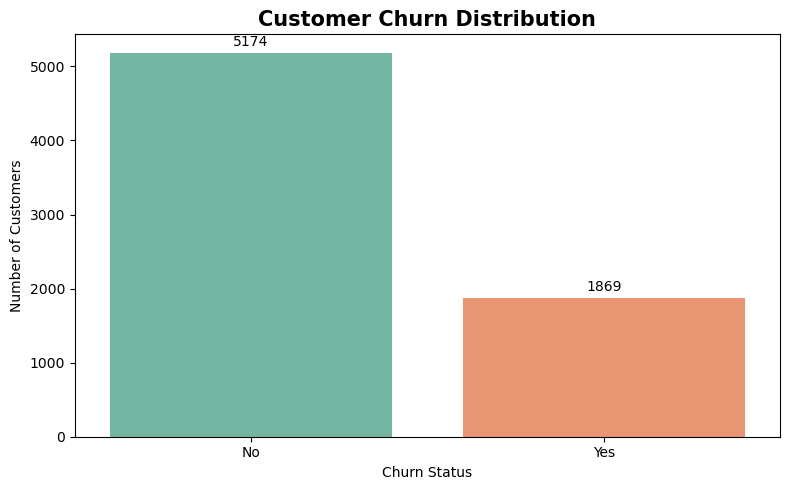

In [141]:
# Bar Chart - Customer Churn Distribution

import matplotlib.pyplot as plt
import seaborn as sns

churn_counts = df['Churn Label'].value_counts()

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    palette='Set2'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

plt.title('Customer Churn Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

# Pie Chart – Churn Percentage

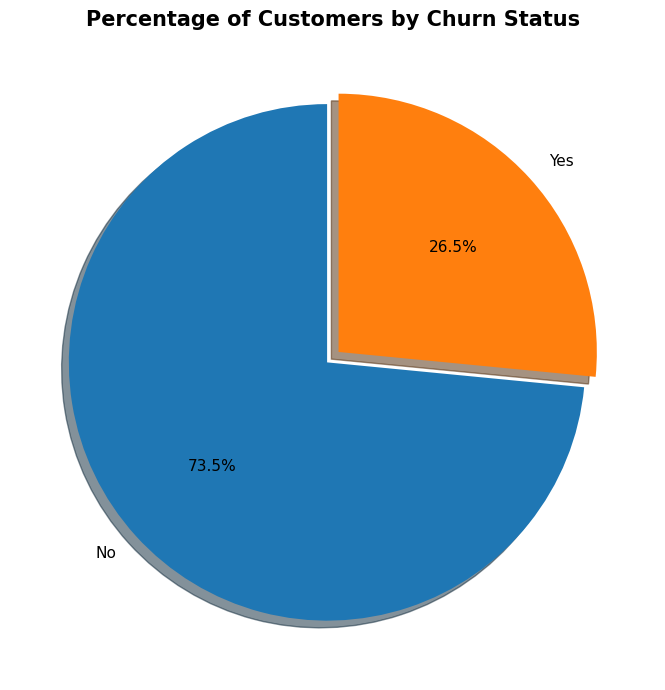

In [142]:
# Pie Chart - Churn Percentage

churn_counts = df['Churn Label'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.03, 0.03],
    shadow=True,
    textprops={'fontsize': 11}
)

plt.title('Percentage of Customers by Churn Status',
          fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

# Horizontal Bar Chart - Churn Rate by Contract

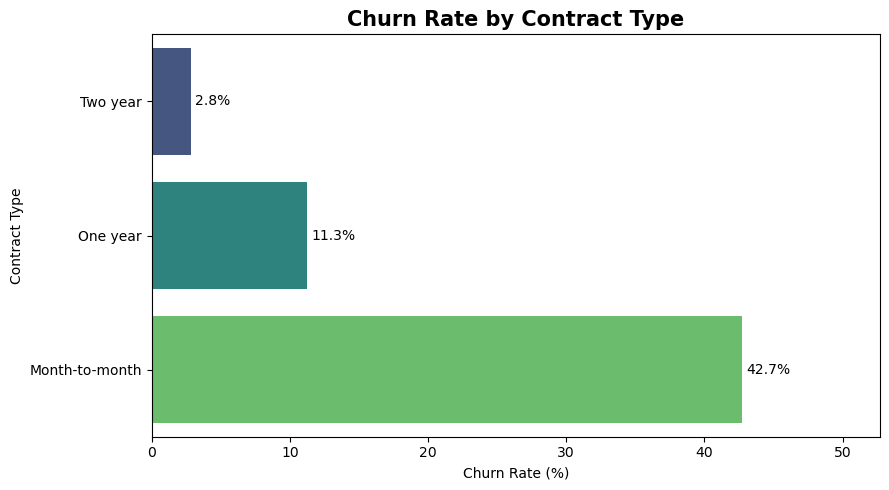

In [143]:
# Horizontal Bar Chart - Churn Rate by Contract

contract_churn = (
    df.groupby('Contract')['Churn Label']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=contract_churn.values,
    y=contract_churn.index,
    palette='viridis'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3,
        fontsize=10
    )

plt.title(
    'Churn Rate by Contract Type',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Churn Rate (%)')
plt.ylabel('Contract Type')

plt.xlim(0, max(contract_churn.values) + 10)

plt.tight_layout()
plt.show()

# Correlation Heatmap

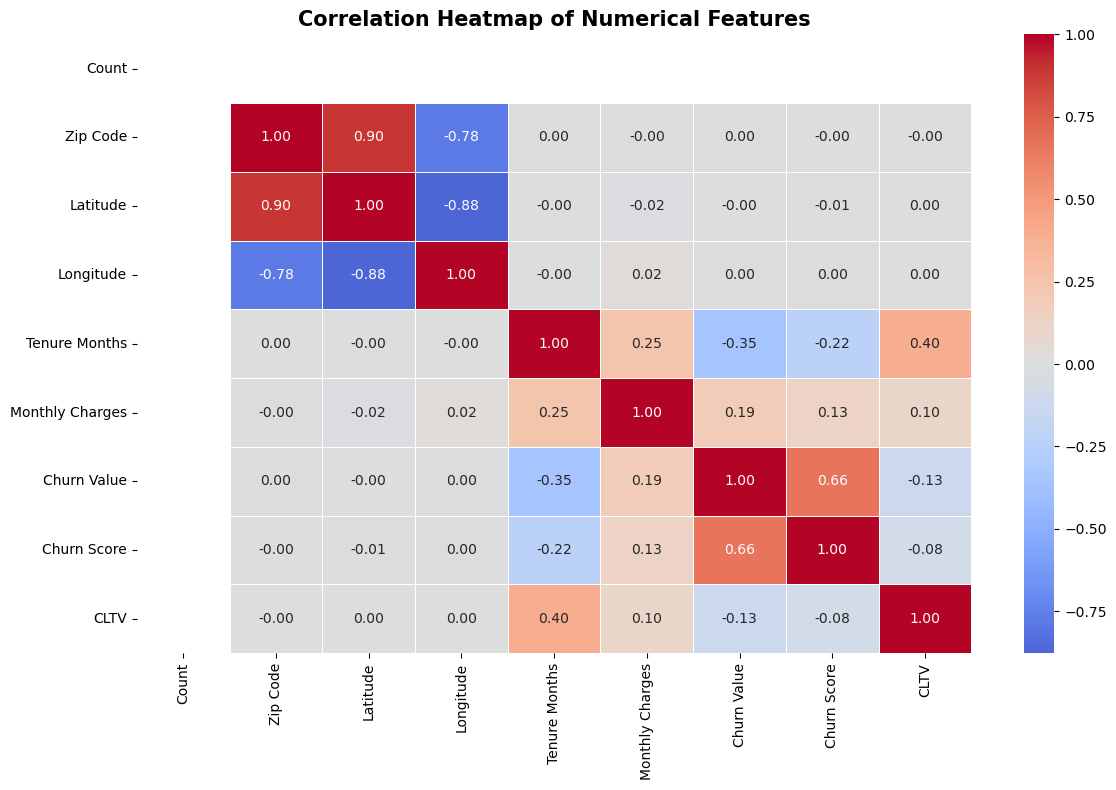

In [144]:
# Correlation Heatmap - Numerical Features

plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    center=0
)

plt.title('Correlation Heatmap of Numerical Features',
          fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Engineering
### The raw data has been converted to a format appropriate for machine learning. The Churn Label has been transformed into a binary target, where churn is considered as 1 and non-churn as 0 for the target (Imani and Arabnia, 2023). One-hot encoding has been done for categorical variables. Categorical missing values have been dropped using the most common category, and numerical missing values have been imputed with the median. The data has then been split into an 80:20 stratified train-test split. Stratification was used to help preserve the 'churn and non-churn' ratio in both datasets in a similar manner.

# Train Test Split and One Hot encoding

In [145]:
# Remove leakage and unnecessary columns
drop = ['CustomerID','Count','Country','State','City','Zip Code',
        'Lat Long','Churn Value','Churn Score','Churn Reason','CLTV']
df = df.drop(columns=drop)

# Target
y = (df['Churn Label'] == 'Yes').astype(int)
X = df.drop(columns='Churn Label')

# Convert object columns to strings BEFORE preprocessing
cat = X.select_dtypes(include=['object']).columns
X[cat] = X[cat].fillna('Unknown').astype(str)

# Numerical columns
num = X.select_dtypes(exclude=['object']).columns

# Preprocessing
pre = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat),
    
    ('num', SimpleImputer(strategy='median'), num)
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


## Logistic Regression Results
### The Logistic Regression model has achieved a cross-validation F1-score of 0.6453 using C=1, balanced class weighting, and the liblinear solver. Test accuracy has reached 76.58%, with 54% precision, 76% recall, and a 0.63 F1-score for churners. The model has identified most customers who churned, although its lower precision has produced some false-positive retention cases. The confusion-matrix values have not been provided.

# Classification Report of Logistic Regression

In [146]:
# Logistic Regression pipeline
lr = Pipeline([
    ('preprocessor', pre),
    ('model', LogisticRegression(max_iter=2000))
])

# Hyperparameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__class_weight': [None, 'balanced']
}

# Grid Search with 5-fold cross-validation
grid_lr = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train and tune
grid_lr.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_lr.best_score_)

# Test prediction
lr_pred = grid_lr.predict(X_test)

print("\nTest Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nClassification Report of Logistic Regression:")
print(classification_report(y_test, lr_pred))

Best Parameters:
{'model__C': 1, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}

Best Cross-Validation F1 Score:
0.6453250405650285

Test Accuracy: 0.765791341376863

Classification Report of Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



# Confusion Matrix of Logistic Regression

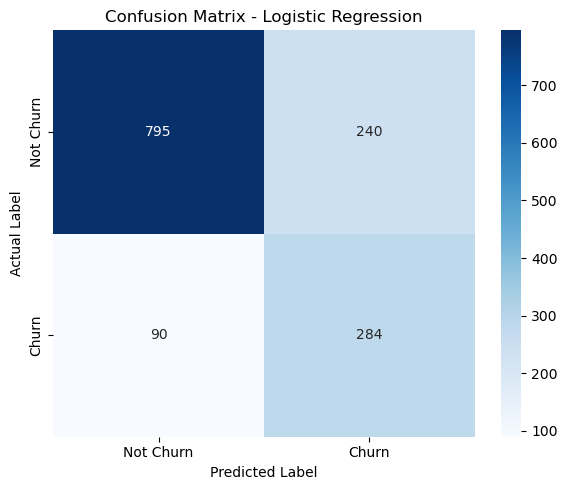

In [147]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Churn', 'Churn'],
    yticklabels=['Not Churn', 'Churn']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

## Random Forest Results
### The Random Forest model has achieved a cross-validation F1-score of 0.6434 using balanced class weighting, 200 trees, maximum depth 20 and minimum split size 5. Test accuracy has reached 75.23%, with 52% precision, 76% recall and a 0.62 F1-score for churners. False negatives have represented actual churners predicted as non-churners, creating missed retention opportunities and potential revenue loss. The confusion-matrix values have not been provided.

# Classification Report of Random Forest

In [148]:
# Random Forest pipeline
rf = Pipeline([
    ('preprocessor', pre),
    ('model', RandomForestClassifier(random_state=42))
])

# Hyperparameter grid
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__class_weight': [None, 'balanced']
}

# Grid Search with 5-fold cross-validation
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train and tune
grid_rf.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_rf.best_score_)

# Test prediction
rf_pred = grid_rf.predict(X_test)

print("\nTest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report of Random Forest:")
print(classification_report(y_test, rf_pred))

Best Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best Cross-Validation F1 Score:
0.6434400685338612

Test Accuracy: 0.752306600425834

Classification Report of Random Forest:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



# Confusion Matrix of Random Forest

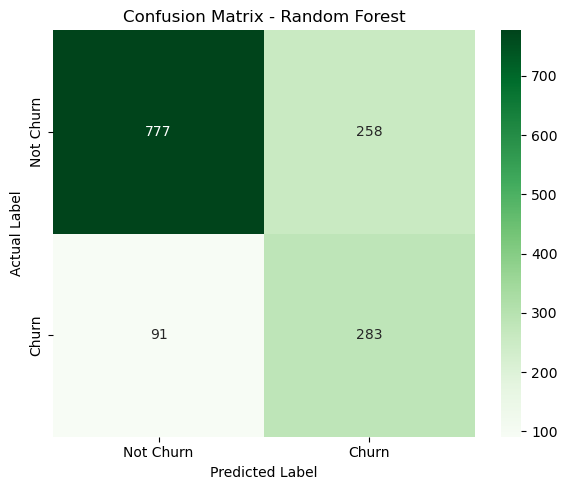

In [149]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Not Churn', 'Churn'],
    yticklabels=['Not Churn', 'Churn']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

## Model Comparison
### The comparison has shown that Logistic Regression has performed slightly better than Random Forest across all evaluation measures. Logistic Regression has achieved 76.58% accuracy, 54.20% precision, 75.94% recall, and an F1-score of 63.25%. Random Forest has achieved 75.23% accuracy, 52.31% precision, 75.07% recall, and an F1-score of 61.86%. Therefore, Logistic Regression has provided stronger overall performance, identifying slightly more churners while maintaining better precision and balanced classification results.

# Model compression using there classfication values

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.765791,0.752307
1,Precision,0.541985,0.523105
2,Recall,0.759358,0.756684
3,F1-Score,0.632517,0.618579


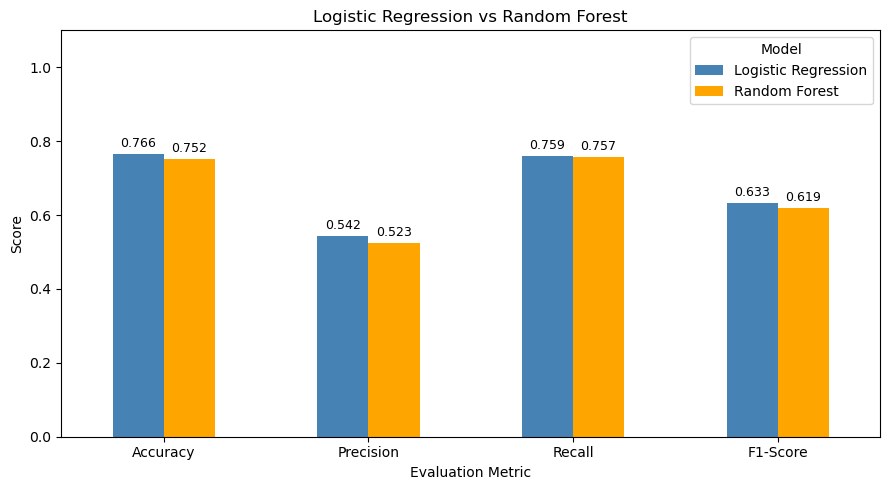

In [150]:
# Calculate performance metrics
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred)
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred)
    ]
})

display(results)

# Create bar chart
ax = results.set_index('Metric').plot(
    kind='bar',
    figsize=(9, 5),
    color=['steelblue', 'orange']
)

# Add values to bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3,
        fontsize=9
    )

plt.title('Logistic Regression vs Random Forest')
plt.xlabel('Evaluation Metric')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

## Business Recommendations
### The results of the model have informed several recommendations for practice. The company should aim to target its highest-risk customers, thereby allowing the customer retention teams to be able to respond in time to the customer. It's possible that month-to-month contracts have a higher churn rate, and the company should explore alternative options like longer contracts, contract incentives, or contract loyalty. Also, review customer-support services for anything that indicates the need for additional support to improve customer satisfaction. Retention plans ought to have been tailored, based on customer data and likelihood of churn, and not to have been blanket. The findings in the model have guided these recommendations, but no statement is made that the recommendations will inevitably lead to more favorable retention results.

## Strengths and Limitations
### The entire pipeline of machine learning has been developed, including data quality checks, data preprocessing, feature transformation, application of two classifiers, hyperparameter optimization, and evaluation on five-fold cross-validation and an unseen test set. The performance evaluation metrics such as accuracy, precision, recall, F1-score, and confusion matrix, have offered a balanced set of metrics to evaluate the model. As for the reported numbers, Logistic Regression shows a slight edge over Random Forest. The data has been an accurate representation of one telecommunications environment and may not have fully captured customers in a different company. Future model reliability could also be affected by changes in historical behaviour that may have occurred over time.


## Conclusion
### The task of this project is to predict the customer churn of a telecom company. It has involved data cleaning, preprocessing, creation of features, and training of Logistic Regression and Random Forest models. The best-performing model is Logistic Regression, which accurately predicts 76.58% of the time, 54.20% of the time with precision, 75.94% of the time with recall, and 63.25% of the time with the F1 score. The results shown have outlined a significant percentage of customers having churnled that were identified by the model. Future work has included a further collection of data, further optimisation, and performance monitoring up to deployment.

## Reference
### erkelmans, G.F., Read, S.H., Gudbjörnsdottir, S., Wild, S.H., Franzen, S., Van Der Graaf, Y., Eliasson, B., Visseren, F.L., Paynter, N.P. and Dorresteijn, J.A., 2022. Population median imputation was noninferior to complex approaches for imputing missing values in cardiovascular prediction models in clinical practice. Journal of clinical epidemiology, 145, pp.70-80. 
### Chang, V., Hall, K., Xu, Q.A., Amao, F.O., Ganatra, M.A. and Benson, V., 2024. Prediction of customer churn behavior in the telecommunication industry using machine learning models. Algorithms, 17(6), p.231.  
### Imani, M. and Arabnia, H.R., 2023. Hyperparameter optimization and combined data sampling techniques in machine learning for customer churn prediction: a comparative analysis. Technologies, 11(6), p.167.  
### Singh, P.P., Anik, F.I., Senapati, R., Sinha, A., Sakib, N. and Hossain, E., 2024. Investigating customer churn in banking: A machine learning approach and visualization app for data science and management. Data Science and Management, 7(1), pp.7-16. 
### Thakur, A.J., 2022. Data presentation: Use of tables and graphics. In Tapping the Power of PowerPoint for Medical Posters and Presentations (pp. 65-81). Singapore: Springer Nature Singapore. 
